# Pipeline Nhận Diện Bàn Cờ ZCR (Semantic Cropping)

Notebook này trình bày thuật toán nhận diện bàn cờ cho tập dữ liệu `zcr*.png` với tính năng **Semantic Cropping**. Môi trường thực tế không chỉ có nhiễu ngoại cảnh (Avatar, UI) mà còn lồng ghép hệ tọa độ (a, b, c, 1, 2) trực tiếp vào lưới. Nếu không được xử lý về mặt **ngữ nghĩa**, các ô tọa độ sẽ bị tính nhầm thành "ô cờ trống", làm sai lệch kích thước thực sự của bàn cờ (ví dụ $19 \times 19$ thay vì $17 \times 17$).

**Thuật toán này giải quyết bằng:**
1. Khử ngoại cảnh bằng Hình thái học (Morphological Filtering).
2. Trích xuất đường kẻ động (Dynamic Grid Lines).
3. Phân loại Ô cờ (Piece) và Ô Nhiễu/Tọa độ (Noise/Coord).
4. Cắt viền ngữ nghĩa (Semantic Cropping) để thu về đúng Playable Area.
5. Số hoá lại bàn cờ (In-painting/Digital Render) có vẽ kèm viền tọa độ.

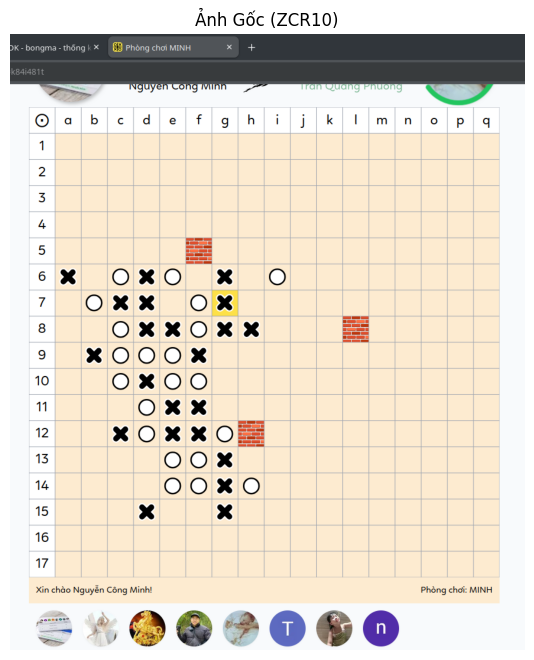

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = 'data/zcr10.png'
img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title('Ảnh Gốc (ZCR10)')
plt.axis('off')
plt.show()

## Bước 1: Khử Ngoại Cảnh & Tìm Bounding Box của Bàn Cờ
Dùng Canny Edge kết hợp `cv2.morphologyEx` để giữ lại các đoạn thẳng dài, tự động bỏ qua Avatar hay Browser UI.

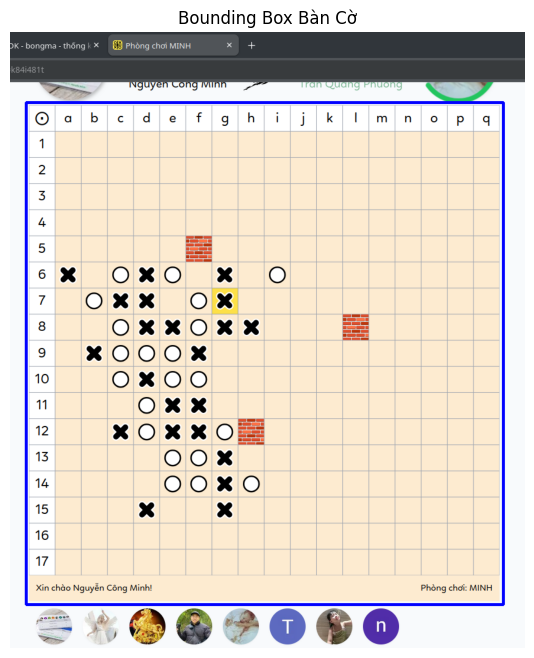

In [15]:
edges_all = cv2.Canny(img_gray, 50, 150)

kernel_h = cv2.getStructuringElement(cv2.MORPH_RECT, (30, 1))
kernel_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 30))

horiz = cv2.morphologyEx(edges_all, cv2.MORPH_OPEN, kernel_h)
vert = cv2.morphologyEx(edges_all, cv2.MORPH_OPEN, kernel_v)
grid_mask = cv2.add(horiz, vert)

kernel_dilate = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
grid_dilated = cv2.dilate(grid_mask, kernel_dilate, iterations=2)

contours, _ = cv2.findContours(grid_dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)
x, y, w, h = cv2.boundingRect(largest_contour)

vis_step1 = img_rgb.copy()
cv2.rectangle(vis_step1, (x, y), (x+w, y+h), (0, 0, 255), 3)

plt.figure(figsize=(10, 8))
plt.imshow(vis_step1)
plt.title('Bounding Box Bàn Cờ')
plt.axis('off')
plt.show()

## Bước 2: Tự Động Trích Xuất Các Đường Kẻ Lưới (Dynamic Grid Projection)
Dùng hình chiếu Edge để tự động tìm tọa độ các đường kẻ mà không cần ép cứng số lượng dòng/cột.

In [16]:
roi_gray = img_gray[y:y+h, x:x+w]
edges = cv2.Canny(roi_gray, 50, 150)

h_proj = edges.sum(axis=1) / 255.0  
v_proj = edges.sum(axis=0) / 255.0  

def get_lines(proj, length):
    thresh = length * 0.2
    lines = []
    in_line = False
    start = 0
    for i, val in enumerate(proj):
        if val > thresh:
            if not in_line:
                in_line = True; start = i
        else:
            if in_line:
                in_line = False; lines.append((start + i - 1) // 2)
    if in_line: lines.append((start + len(proj) - 1) // 2)
        
    grouped = []
    if not lines: return []
    curr = [lines[0]]
    for i in range(1, len(lines)):
        if lines[i] - curr[-1] < 10: curr.append(lines[i])
        else: grouped.append(int(np.mean(curr))); curr = [lines[i]]
    if curr: grouped.append(int(np.mean(curr)))
    return grouped

h_lines = get_lines(h_proj, w)
v_lines = get_lines(v_proj, h)

print(f"Số dòng tìm được: {len(h_lines) - 1}, số cột: {len(v_lines) - 1}")

Số dòng tìm được: 19, số cột: 19


## Bước 3: Phân Loại Ma Trận "Ngữ Nghĩa" (Semantic Classification)
Tại bước này, ngoài việc nhận diện `X`, `O`, `W`, ta sẽ đặc biệt tìm ra các ô Nhiễu/Tọa độ. Chúng được gán cờ `C`.
Đặc trưng: Ô tọa độ/chữ luôn có diện tích điểm đen rất nhỏ (`max_area` khoảng 5 đến 200). Quân cờ lớn hơn 200.

In [17]:
semantic_matrix = []

for r in range(len(h_lines) - 1):
    row_sem = []
    for c in range(len(v_lines) - 1):
        top = h_lines[r]; bottom = h_lines[r+1]
        left = v_lines[c]; right = v_lines[c+1]
        
        cell_w = right - left
        cell_h = bottom - top
        if cell_w < 10 or cell_h < 10: continue
        
        margin_x = int(cell_w * 0.15)
        margin_y = int(cell_h * 0.15)
        cell_img = img_bgr[y+top+margin_y:y+bottom-margin_y, x+left+margin_x:x+right-margin_x]
        
        if cell_img.size == 0: 
            row_sem.append('.')
            continue
            
        cell_gray = cv2.cvtColor(cell_img, cv2.COLOR_BGR2GRAY)
        hsv_cell = cv2.cvtColor(cell_img, cv2.COLOR_BGR2HSV)
        
        mean_s = np.mean(hsv_cell[:, :, 1])
        var_gray = np.var(cell_gray)
        edge_ratio = np.mean(cv2.Canny(cell_gray, 50, 150)) / 255.0
        
        _, thresh_dark = cv2.threshold(cell_gray, 120, 255, cv2.THRESH_BINARY_INV)
        contours_dark, _ = cv2.findContours(thresh_dark, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        max_area = max([cv2.contourArea(cnt) for cnt in contours_dark]) if contours_dark else 0
        
        cls = '.'
        if edge_ratio > 0.2 and mean_s > 100: cls = 'W'
        elif max_area >= 200:
            ch, cw = cell_gray.shape
            center_mean = np.mean(cell_gray[ch//2-3:ch//2+4, cw//2-3:cw//2+4])
            cls = 'O' if center_mean > 160 else 'X'
        elif 5 < max_area < 200 and var_gray > 500:
            cls = 'C' # Tọa độ hoặc Text (Noise)
            
        row_sem.append(cls)
    semantic_matrix.append(row_sem)

print("Ma trận ban đầu (chưa cắt):")
for r, row in enumerate(semantic_matrix):
    print(f"R{r:02d}: " + " ".join(row))

Ma trận ban đầu (chưa cắt):
R00: C C C C C C C C C C C C C C C C C C C
R01: . C . . . . . . . . . . . . . . . . .
R02: . C . . . . . . . . . . . . . . . . .
R03: . C . . . . . . . . . . . . . . . . .
R04: . C . . . . . . . . . . . . . . . . .
R05: . C . . . . . W . . . . . . . . . . .
R06: . C X . O X O . X . O . . . . . . . .
R07: . C . O X X . O X . . . . . . . . . .
R08: . C . . O X X O X X . . . W . . . . .
R09: . C . X O O O X . . . . . . . . . . .
R10: . C . . O X O O . . . . . . . . . . .
R11: . C . . . O X X . . . . . . . . . . .
R12: . C . . X O X X O W . . . . . . . . .
R13: . C . . . . O O X . . . . . . . . . .
R14: . C . . . . O O X O . . . . . . . . .
R15: . C . . . X . . X . . . . . . . . . .
R16: . C . . . . . . . . . . . . . . . . .
R17: . C . . . . . . . . . . . . . . . . .
R18: . . C C C C . . . . . . . . . . C C C


## Bước 4: Cắt Viền Ngữ Nghĩa (Semantic Cropping)
Phân tích `semantic_matrix`:
Bất kỳ dòng/cột nào ở viền chứa nhiều ký tự `C` (>= 3) đều là dòng/cột tọa độ/banner và phải bị cắt bỏ.
Điều này giúp trả về một bàn cờ nguyên chất 100% Playable Area ($17 \times 17$).

In [18]:
num_rows = len(semantic_matrix)
num_cols = len(semantic_matrix[0]) if num_rows > 0 else 0

# Tìm tất cả các dòng/cột bị gán nhãn Tọa Độ (chứa nhiều 'C')
coord_rows = [r for r in range(num_rows) if semantic_matrix[r].count('C') >= 3]
coord_cols = [c for c in range(num_cols) if [semantic_matrix[r][c] for r in range(num_rows)].count('C') >= 3]

# Xác định ranh giới cắt
top_limit = max([r for r in coord_rows if r < num_rows/2], default=-1) + 1
bottom_limit = min([r for r in coord_rows if r > num_rows/2], default=num_rows)

left_limit = max([c for c in coord_cols if c < num_cols/2], default=-1) + 1
right_limit = min([c for c in coord_cols if c > num_cols/2], default=num_cols)

# Cắt cúp mảng (Cropping)
playable_matrix = []
for r in range(top_limit, bottom_limit):
    row_data = semantic_matrix[r][left_limit:right_limit]
    # Sau khi cắt, các ô 'C' lẻ tẻ còn sót lại được chuyển thành '.'
    row_data = ['.' if cell == 'C' else cell for cell in row_data]
    playable_matrix.append(row_data)

play_h = len(playable_matrix)
play_w = len(playable_matrix[0]) if play_h > 0 else 0

print(f"Kích thước lõi bàn cờ Playable Area: {play_h} x {play_w}")
for r, row in enumerate(playable_matrix):
    print(f"R{r:02d}: " + " ".join(row))

Kích thước lõi bàn cờ Playable Area: 17 x 17
R00: . . . . . . . . . . . . . . . . .
R01: . . . . . . . . . . . . . . . . .
R02: . . . . . . . . . . . . . . . . .
R03: . . . . . . . . . . . . . . . . .
R04: . . . . . W . . . . . . . . . . .
R05: X . O X O . X . O . . . . . . . .
R06: . O X X . O X . . . . . . . . . .
R07: . . O X X O X X . . . W . . . . .
R08: . X O O O X . . . . . . . . . . .
R09: . . O X O O . . . . . . . . . . .
R10: . . . O X X . . . . . . . . . . .
R11: . . X O X X O W . . . . . . . . .
R12: . . . . O O X . . . . . . . . . .
R13: . . . . O O X O . . . . . . . . .
R14: . . . X . . X . . . . . . . . . .
R15: . . . . . . . . . . . . . . . . .
R16: . . . . . . . . . . . . . . . . .


## Bước 5: In-painting Cải Tiến (Render Số Hóa Tọa Độ Viền)
Dựa trên ma trận `playable_matrix` đã được "lọc lõi", ta vẽ lại bàn cờ sạch, đồng thời tự chèn ký tự tọa độ chữ `a-q` và số `1-17` ra khoảng lề (Margin) để thể hiện rõ ngữ nghĩa đúng như user yêu cầu.

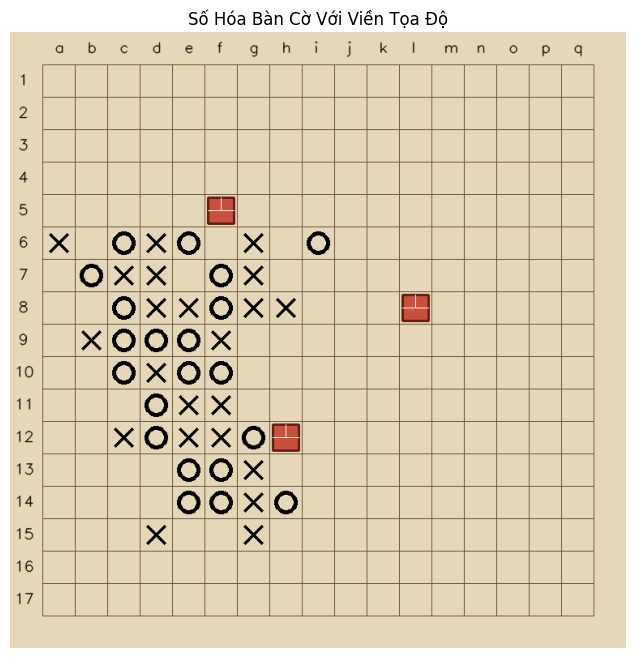

In [19]:
cell_size = 40
margin = 40 # Mở rộng lề để ghi tọa độ

width = play_w * cell_size + 2 * margin
height = play_h * cell_size + 2 * margin

digital_board = np.full((height, width, 3), (230, 215, 185), dtype=np.uint8)

# Vẽ lưới
for r in range(play_h + 1):
    py = margin + r * cell_size
    cv2.line(digital_board, (margin, py), (width - margin, py), (100, 80, 60), 1)
for c in range(play_w + 1):
    px = margin + c * cell_size
    cv2.line(digital_board, (px, margin), (px, height - margin), (100, 80, 60), 1)

# Vẽ Tọa Độ Viền
letters = "abcdefghijklmnopqrstuvwxyz"
for c in range(play_w):
    char = letters[c] if c < len(letters) else "?"
    cx = margin + c * cell_size + cell_size // 2 - 5
    cy = margin - 15
    cv2.putText(digital_board, char, (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 1, cv2.LINE_AA)

for r in range(play_h):
    num = str(r + 1)
    cx = margin - 30 if len(num) == 1 else margin - 35
    cy = margin + r * cell_size + cell_size // 2 + 5
    cv2.putText(digital_board, num, (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 1, cv2.LINE_AA)

# Vẽ quân cờ và tường
for r in range(play_h):
    for c in range(play_w):
        cls = playable_matrix[r][c]
        cx = margin + c * cell_size + cell_size // 2
        cy = margin + r * cell_size + cell_size // 2
        
        if cls == 'W':
            cv2.rectangle(digital_board, (cx - cell_size//2 + 4, cy - cell_size//2 + 4), 
                          (cx + cell_size//2 - 4, cy + cell_size//2 - 4), (200, 80, 60), -1)
            cv2.rectangle(digital_board, (cx - cell_size//2 + 4, cy - cell_size//2 + 4), 
                          (cx + cell_size//2 - 4, cy + cell_size//2 - 4), (100, 30, 20), 2)
            cv2.line(digital_board, (cx - cell_size//2 + 4, cy), (cx + cell_size//2 - 4, cy), (255,255,255), 1)
            cv2.line(digital_board, (cx, cy - cell_size//2 + 4), (cx, cy), (255,255,255), 1)
        elif cls == 'X':
            thick = 4
            cv2.line(digital_board, (cx - 10, cy - 10), (cx + 10, cy + 10), (0, 0, 0), thick)
            cv2.line(digital_board, (cx + 10, cy - 10), (cx - 10, cy + 10), (0, 0, 0), thick)
        elif cls == 'O':
            cv2.circle(digital_board, (cx, cy), 12, (0, 0, 0), 3)

plt.figure(figsize=(10, 8))
plt.imshow(digital_board)
plt.title('Số Hóa Bàn Cờ Với Viền Tọa Độ')
plt.axis('off')
plt.show()